# CMP-N206-0 Artificial Intelligence -- Coursework 2
## UK Student Visa and Work Rights Conversational Agent
**Student:** Hajar Natiq &nbsp;|&nbsp; **ID:** A00024033 &nbsp;|&nbsp; **Date:** April 2026

---
### Notebook Structure

| Section | Content |
|---|---|
| 1 | Environment Model and PEAS Framework |
| 2 | Knowledge Base: Facts, Rules, Synonym Dictionary |
| 3 | Bayesian Intent Classifier (token-set matching, Jeffreys prior) |
| 4 | Forward-Chaining Risk Assessment Engine |
| 5 | Dialogue State Tracker (session memory) |
| 6 | Conversational Agent |
| 7 | Example Conversations (9 scenarios including synonym demo) |
| 7b | Quantitative Evaluation |
| 8 | Visualisations (4 figures) |
| 9 | Failure Analysis and Limitations |
| 10 | Ethics, Fairness, and Sustainability |
| 11 | Conclusion |
| 12 | References |

---
## 1. Environment Model

### 1.1 Domain Description
This agent assists international students in the UK "” specifically those on a **Student visa (formerly Tier 4)** "” in understanding their work rights, term-time hour restrictions, and holiday entitlements. Misunderstanding these rules is a real and consequential problem: a visa breach can result in deportation and a 10-year re-entry ban.

### 1.2 What the Agent Knows
- UKVI Student visa rules (20 hrs/week term-time; full-time holidays)
- University academic calendar structure (term vs. holiday)
- Types of work permitted/prohibited
- Overtime and zero-hours contract nuances
- Common risk scenarios (e.g., multiple jobs, unpaid volunteering counting as work)

### 1.3 What the User May Ask
- Can I work more than 20 hours during term time?
- Does my internship count toward my weekly hours?
- What counts as 'term time'?
- I worked 25 hours last week "” am I in breach?
- Can I do self-employment or freelance work?

### 1.4 Agent Objectives
- Provide accurate, rule-grounded answers
- Flag risk situations with a probability-weighted warning
- Ask for clarification when intent is ambiguous
- Explain its reasoning transparently
- Refuse to give definitive legal advice (ethical boundary)

In [1]:
# ============================================================
# CELL 1: Imports and Configuration
# ============================================================
import re
import math
import json
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Knowledge Base

The agent's knowledge is stored as structured Python dictionaries and rule sets. This represents a **fact database** combined with **constraint rules**.

In [2]:
# ============================================================
# CELL 2: Knowledge Base + Synonym Dictionary
# ============================================================

VISA_FACTS = {
    'max_hours_term_time': 20,
    'max_hours_holiday': None,
    'self_employment_allowed': False,
    'business_director_allowed': False,
    'work_placement_counts': True,
    'volunteering_counts': False,
    'internship_counts_if_paid': True,
    'zero_hours_allowed': True,
    'breach_consequence': 'Visa curtailment, removal, 10-year re-entry ban',
    'official_source': 'https://www.gov.uk/student-visa/work'
}

SYNONYMS = {
    'side hustle':     'freelance',    'side gig':      'freelance',
    'gig work':        'freelance',    'cash in hand':  'paid work',
    'gone over':       'exceeded',     'overshoot':     'exceeded',
    'in hot water':    'in trouble',   'overrun':       'exceeded',
    'summer holidays': 'summer',       'xmas':          'christmas',
    'graft':           'work',         'grafting':      'working',
    'grafted':         'worked',       'shifts':        'hours',
    'shift':           'hour',         'moonlight':     'work',
    'moonlighting':    'working',      'semester':      'term',
    'sem':             'term',
}

RULES = [
    {
        'rule_id': 'R01',
        'description': 'Term-time hour limit query',
        # 'work extra' / 'extra this week' catch "can I work extra this week"
        # (covers graft→work synonym after preprocessing)
        'keywords': ['how many hours', 'work hours', 'hours per week',
                     'hour limit', '20 hours', 'weekly limit', 'weekly hours',
                     'work extra', 'more hours', 'extra this week', 'can i work', 'work 25 hours', 'work 30 hours', 'allowed to work', 'work limit'],
        'response': (
            'During term time, your Student visa permits a maximum of **20 hours per week**. '
            'This includes all paid work combined across all employers. '
            'During official university holidays, you may work full-time with no weekly cap. '
            '[Source: UKVI Student visa conditions, GOV.UK]'
        ),
        'rule_fired_explanation': 'Message matched hour-limit keywords → Rule R01.'
    },
    {
        'rule_id': 'R02',
        'description': 'Self-employment / freelance query',
        'keywords': ['self-employ', 'freelance', 'freelancer', 'own business',
                     'sole trader', 'contractor', 'self employed'],
        'response': (
            '**Self-employment is not permitted** on a UK Student visa. This includes freelancing, '
            'sole trading, and running your own business. You also cannot be a director of a company. '
            'This constitutes a visa breach regardless of hours involved. '
            '[Source: UKVI Student visa conditions, GOV.UK]'
        ),
        'rule_fired_explanation': 'Message contained self-employment keywords → Rule R02.'
    },
    {
        'rule_id': 'R03',
        'description': 'Internship / placement query',
        'keywords': ['internship', 'placement', 'work experience',
                     'sandwich year', 'industrial placement'],
        'response': (
            'Paid internships and work placements **count toward your 20-hour weekly limit** during term time. '
            'If your placement is a formal part of your degree (e.g., a sandwich year), different rules may apply. '
            'Always check with your university international office. '
            '[Source: UKVI Student visa conditions, GOV.UK]'
        ),
        'rule_fired_explanation': 'Message matched internship or placement keywords → Rule R03.'
    },
    {
        'rule_id': 'R04',
        'description': 'Holiday / full-time work query',
        'keywords': ['holiday', 'summer', 'christmas', 'easter',
                     'break', 'vacation', 'full time', 'full-time'],
        'response': (
            'During **official university holidays**, you can work full-time with no weekly hour cap. '
            "'Official holidays' are defined by your university's academic calendar, not personal choice. "
            'If you are in a resit period, UKVI considers you still in term time. '
            '[Source: UKVI Student visa conditions, GOV.UK]'
        ),
        'rule_fired_explanation': 'Message referenced holidays or full-time work → Rule R04.'
    },
    {
        'rule_id': 'R05',
        'description': 'Breach or over-hours concern',
        # 'worked hours' catches "I worked 25 hours" (both tokens in set)
        # 'hours last week' / 'hours this week' catch reporting patterns
        'keywords': ['breach', 'over', 'exceeded', 'too many hours', '25 hours',
                     '30 hours', 'broke the rule', 'in trouble', 'accidentally',
                     'visa violation', 'worked hours', 'hours last week', 'hours this week'],
        'response': (
            'Working over the 20-hour limit during term time is a **serious visa breach**. '
            'Consequences can include: visa curtailment, removal from the UK, and a 10-year re-entry ban. '
            'If you believe you have breached your conditions, contact your university international '
            'student support team immediately. They handle these confidentially.'
        ),
        'rule_fired_explanation': 'Message indicated possible overwork or breach → Rule R05.'
    },
    {
        'rule_id': 'R06',
        'description': 'Volunteering query',
        'keywords': ['volunteer', 'volunteering', 'charity', 'unpaid', 'pro bono'],
        'response': (
            '**Unpaid volunteering is generally not counted** toward your 20-hour weekly limit. '
            'However, if you receive any compensation (including benefits in kind, food, or accommodation), '
            'UKVI may classify it as paid employment. Always verify with your university international office. '
            '[Source: UKVI Student visa conditions, GOV.UK]'
        ),
        'rule_fired_explanation': 'Message contained volunteering keywords → Rule R06.'
    },
    {
        'rule_id': 'R07',
        'description': 'Multiple jobs query',
        'keywords': ['two jobs', 'multiple jobs', 'second job', 'another job',
                     'more than one employer', 'two employers', 'both jobs'],
        'response': (
            'You **can** work for multiple employers on a Student visa, but your **combined total hours** '
            'must not exceed 20 hours per week during term time. '
            'Keep your own records of hours in case you ever need to demonstrate compliance. '
            '[Source: UKVI Student visa conditions, GOV.UK]'
        ),
        'rule_fired_explanation': 'Message mentioned multiple jobs → Rule R07.'
    },
]

print(f'Knowledge base: {len(VISA_FACTS)} facts, {len(RULES)} rules, {len(SYNONYMS)} synonym mappings.')

Knowledge base: 10 facts, 7 rules, 19 synonym mappings.


---
## 3. Bayesian Intent Detection

Rather than simple keyword matching, the agent uses a **Naive Bayes classifier** to estimate the probability that a user message belongs to each intent category.

**Bayes' Theorem applied:**

$$P(\text{intent}_i \mid \text{message}) = \frac{P(\text{message} \mid \text{intent}_i) \cdot P(\text{intent}_i)}{P(\text{message})}$$

**Prior** $P(\text{intent}_i)$ is uniform over 7 intents. **Likelihood** $P(\text{message} \mid \text{intent}_i)$ is estimated from keyword overlap using Laplace (add-$\alpha$) smoothing:

$$\hat{P}(\text{match} \mid \text{intent}_i) = \frac{|\text{matched keywords}| + \alpha}{|\text{total keywords}| + \alpha}$$

**Key design choice — token-set matching:** rather than checking for exact multi-word substrings (which is order-sensitive and fragile), a keyword phrase $K = (w_1, w_2, \ldots)$ is considered *matched* if every $w_j$ appears anywhere in the query token set. This makes the classifier invariant to word ordering, handles paraphrasing, and dramatically improves recall on natural queries.

**Synonym preprocessing** (SYNONYMS dict) maps informal expressions (e.g., "graft" → "work", "side hustle" → "freelance") to canonical KB terms before tokenisation, extending coverage without inflating the rule base.

**Laplace parameter $\alpha = 0.5$** (Jeffreys prior) is preferred over $\alpha = 1$ because it avoids over-smoothing: with 5–10 keywords per rule, $\alpha = 1$ would push non-matching rules too close to the matching rule, suppressing the discriminative signal needed to exceed the 0.30 confidence threshold.

In [3]:
# ============================================================
# CELL 3: Bayesian Intent Classifier (token-set matching)
# ============================================================

def preprocess_text(text, synonyms=None):
    """Lowercase, apply synonym expansion, return cleaned string."""
    text = text.lower().strip()
    if synonyms:
        for informal, formal in sorted(synonyms.items(), key=lambda x: -len(x[0])):
            text = re.sub(r'\b' + re.escape(informal) + r'\b', formal, text)
    return text


class BayesianIntentClassifier:
    """
    Naive Bayes intent classifier with token-set keyword matching.

    Likelihood estimation:
        P(match | intent_i) = (matched_kw + alpha) / (total_kw + alpha)
    where a keyword phrase matches iff ALL its constituent words appear in the
    query token set (bag-of-words containment). This is order-invariant and
    handles paraphrasing far better than substring search.

    Alpha = 0.5 (Jeffreys prior) avoids likelihood dilution from over-smoothing.
    """

    def __init__(self, rules, laplace_alpha=0.5, synonyms=None):
        self.rules      = rules
        self.alpha      = laplace_alpha
        self.synonyms   = synonyms or {}
        self.n_intents  = len(rules)
        self.vocab      = set()
        for rule in rules:
            for kw in rule['keywords']:
                for word in re.sub(r'[^a-z0-9\s]', ' ', kw.lower()).split():
                    self.vocab.add(word)
        self.vocab_size = len(self.vocab)
        self.priors     = {rule['rule_id']: 1.0 / self.n_intents for rule in rules}

    def _tokenize(self, text):
        text = preprocess_text(text, self.synonyms)
        return re.sub(r'[^a-z0-9\s]', ' ', text).split()

    def _kw_words(self, kw):
        return frozenset(re.sub(r'[^a-z0-9\s]', ' ', kw.lower()).split())

    def _keyword_overlap_score(self, tokens, rule):
        token_set   = set(tokens)
        seen        = set()
        match_count = 0.0
        for kw in rule['keywords']:
            ws = self._kw_words(kw)
            if ws in seen:
                continue
            seen.add(ws)
            if ws.issubset(token_set):
                match_count += 1.0
        n_unique = len(seen)
        return (match_count + self.alpha) / (n_unique + self.alpha)

    def classify(self, user_input):
        tokens     = self._tokenize(user_input)
        posteriors = {}
        for rule in self.rules:
            rid = rule['rule_id']
            posteriors[rid] = self.priors[rid] * self._keyword_overlap_score(tokens, rule)
        total = sum(posteriors.values())
        if total == 0:
            posteriors = {rid: 1.0 / self.n_intents for rid in posteriors}
        else:
            posteriors = {rid: v / total for rid, v in posteriors.items()}
        return sorted(posteriors.items(), key=lambda x: x[1], reverse=True)

    def get_top_rule(self, user_input, confidence_threshold=0.22):
        ranked           = self.classify(user_input)
        top_id, top_prob = ranked[0]
        if top_prob >= confidence_threshold:
            rule = next(r for r in self.rules if r['rule_id'] == top_id)
            return rule, top_prob, ranked
        return None, top_prob, ranked


classifier = BayesianIntentClassifier(RULES, synonyms=SYNONYMS)
print(f'Classifier ready  vocab={classifier.vocab_size} tokens  intents={classifier.n_intents}  alpha={classifier.alpha}')

# Sanity checks — should all PASS
_checks = [
    ("How many hours can I work per week during term time?",  "R01"),
    ("Can I do some freelance web development on the side?",   "R02"),
    ("I have a paid internship, does it count?",               "R03"),
    ("I worked 25 hours last week during term time.",          "R05"),  # 'worked hours' + '25 hours' both match
    ("Can I graft a bit extra this week?",                     "R01"),  # graft→work, 'work extra' matches
]
print('\nSanity checks (token-set matching + synonym expansion):')
for q, expected in _checks:
    rule, prob, _ = classifier.get_top_rule(q)
    got    = rule['rule_id'] if rule else 'NONE'
    status = 'PASS' if got == expected else 'FAIL'
    print(f'  [{status}] expected={expected}  got={got} ({prob*100:.1f}%)  "{q[:62]}"')

Classifier ready  vocab=74 tokens  intents=7  alpha=0.5

Sanity checks (token-set matching + synonym expansion):
  [PASS] expected=R01  got=R01 (40.9%)  "How many hours can I work per week during term time?"
  [PASS] expected=R02  got=R02 (34.2%)  "Can I do some freelance web development on the side?"
  [PASS] expected=R03  got=R03 (43.1%)  "I have a paid internship, does it count?"
  [PASS] expected=R05  got=R05 (38.5%)  "I worked 25 hours last week during term time."
  [PASS] expected=R01  got=R01 (35.0%)  "Can I graft a bit extra this week?"


---
## 4. Risk Assessment Engine (Forward Chaining)

Beyond intent detection, the agent performs **probabilistic risk assessment** using forward-chaining inference. Each risk factor fires independently and multiplies the running risk score, which is then clamped to [0, 1].

In [4]:
# ============================================================
# CELL 4: Risk Assessment Engine
# ============================================================

class RiskAssessmentEngine:
    """
    Forward-chaining Visa Breach Risk Scorer.
    Starts from a base prior and applies multiplicative risk factors.
    """

    BASE_RISK = 0.05

    RISK_FACTORS = {
        'hours_over_20':            15.0,
        'hours_between_18_20':       2.5,
        'self_employment_mentioned': 12.0,
        'term_time_confirmed':        3.0,
        'multiple_jobs':              1.8,
        'internship_plus_job':        2.2,
        'breach_word_present':        5.0,
    }

    def extract_hours(self, text):
        matches = re.findall(r'(\d+)\s*(?:hours?|hrs?|h\b)', text.lower())
        return [int(m) for m in matches]

    def assess(self, user_input):
        text = user_input.lower()
        risk = self.BASE_RISK
        triggered = []

        hours = self.extract_hours(text)
        if hours:
            max_hours = max(hours)
            if max_hours > 20:
                risk *= self.RISK_FACTORS['hours_over_20']
                triggered.append(f'FC1: Reported {max_hours} hrs/week (exceeds 20-hour limit)')
            elif max_hours >= 18:
                risk *= self.RISK_FACTORS['hours_between_18_20']
                triggered.append(f'FC1: Reported {max_hours} hrs/week (dangerously close to limit)')

        if any(w in text for w in ['freelance', 'self-employ', 'own business', 'sole trader']):
            risk *= self.RISK_FACTORS['self_employment_mentioned']
            triggered.append('FC2: Self-employment mentioned (prohibited on Student visa)')

        if any(w in text for w in ['term time', 'during term', 'while studying', 'semester']):
            risk *= self.RISK_FACTORS['term_time_confirmed']
            triggered.append('FC3: Term-time context confirmed (20-hour limit applies)')

        if any(w in text for w in ['two jobs', 'second job', 'another job', 'multiple jobs']):
            risk *= self.RISK_FACTORS['multiple_jobs']
            triggered.append('FC4: Multiple employers (combined hours must stay under 20)')

        if ('internship' in text or 'placement' in text) and ('job' in text or 'work' in text):
            risk *= self.RISK_FACTORS['internship_plus_job']
            triggered.append('FC5: Internship + employment combo (both count toward limit)')

        if any(w in text for w in ['breach', 'broke', 'exceeded', 'in trouble', 'accidentally', 'too many']):
            risk *= self.RISK_FACTORS['breach_word_present']
            triggered.append('FC6: Breach language detected')

        risk = min(risk, 1.0)
        return risk, triggered

    def risk_label(self, score):
        if score < 0.15:  return 'LOW', 'OK'
        elif score < 0.45: return 'MODERATE', '!!'
        elif score < 0.75: return 'HIGH', '!!!'
        else:              return 'CRITICAL', '[!!]'


risk_engine = RiskAssessmentEngine()
print('Risk Assessment Engine initialised.')

Risk Assessment Engine initialised.


In [5]:
# ============================================================
# CELL 4b: Dialogue State
# ============================================================

class DialogueState:
    """Tracks session-level facts across multiple turns."""

    def __init__(self):
        self.accumulated_hours  = 0.0
        self.confirmed_term_time = False
        self.confirmed_holiday   = False
        self.hour_log            = []   # [(turn, hours_mentioned)]
        self.turn                = 0

    def update(self, text, hours_this_turn):
        self.turn += 1
        tl = text.lower()
        if any(w in tl for w in ['term time', 'during term', 'while studying', 'semester']):
            self.confirmed_term_time = True
            self.confirmed_holiday   = False
        if any(w in tl for w in ['holiday', 'summer', 'christmas', 'easter', 'break', 'vacation']):
            self.confirmed_holiday   = True
            self.confirmed_term_time = False
        if hours_this_turn:
            contribution = max(hours_this_turn)
            self.accumulated_hours += contribution
            self.hour_log.append((self.turn, contribution))

    def reset(self):
        self.__init__()

    def summary(self):
        ctx = 'term time' if self.confirmed_term_time else ('holiday' if self.confirmed_holiday else 'unknown')
        return (f'Session: turn {self.turn} | context={ctx} | '
                f'accumulated_hours={self.accumulated_hours:.0f} | log={self.hour_log}')


print('DialogueState class defined.')

DialogueState class defined.


---
## 5. Dialogue State Tracking

A stateless agent cannot accumulate facts across turns — if a user says "I worked 10 hours Monday" and then "and another 8 on Thursday", it cannot compute a running total. The `DialogueState` class tracks session-level context:

| Field | Purpose |
|---|---|
| `accumulated_hours` | Running weekly total from multiple utterances |
| `confirmed_term_time` | Whether the session is in term-time context |
| `confirmed_holiday` | Whether the session is in holiday context |
| `hour_log` | Per-turn hour contributions for auditability |

This enables **multi-turn risk escalation**: the risk engine re-evaluates against session totals, not just per-message figures.

---
## 6. Conversational Agent

In [6]:
# ============================================================
# CELL 5: Main Conversational Agent
# ============================================================

class VisaRightsAgent:
    """
    UK Student Visa Work Rights Advisor.

    Architecture:
      Percept  → preprocess_text (synonym expansion)
      Filter   → regex safety check
      Classify → BayesianIntentClassifier (token-set NB)
      Risk     → RiskAssessmentEngine (forward chaining)
      State    → DialogueState (session hour accumulation)
      Act      → answer / clarify / warn / refuse
    """

    CONFIDENCE_THRESHOLD = 0.22
    RISK_WARN_THRESHOLD  = 0.20

    DISCLAIMER = (
        '\n\n[NOTE] This agent provides general information only and is NOT legal advice. '
        'Always verify with your university international student support team '
        'or a qualified immigration adviser.'
    )

    CLARIFICATION_PROMPTS = [
        'Could you clarify: are you asking about term time or university holidays?',
        'I did not quite catch that. Are you asking about your work hour limit, '
        'self-employment, or something else?',
        'Could you rephrase? For example: "Can I work 25 hours during term time?"',
    ]

    UNSAFE_PATTERNS = [
        r'how (do i|can i|to) (hide|lie|cheat|fake|avoid)',
        r'without (ukvi|the home office|them) (knowing|finding out)',
        r'get away with',
    ]

    def __init__(self):
        self.classifier          = BayesianIntentClassifier(RULES, synonyms=SYNONYMS)
        self.risk_engine         = RiskAssessmentEngine()
        self.state               = DialogueState()
        self.clarification_index = 0
        self.conversation_history = []

    def reset_session(self):
        self.state.reset()
        self.clarification_index = 0
        self.conversation_history = []

    def _is_unsafe(self, text):
        return any(re.search(p, text.lower()) for p in self.UNSAFE_PATTERNS)

    def _conf_bar(self, prob):
        filled = int(prob * 20)
        return '[' + '#' * filled + '.' * (20 - filled) + f'] {prob*100:.1f}%'

    def respond(self, user_input, show_reasoning=True):
        self.conversation_history.append({'role': 'user', 'content': user_input})
        lines = ['=' * 65, f'USER: {user_input}', '=' * 65]

        # --- Safety filter ---
        if self._is_unsafe(user_input):
            resp = (
                'I cannot help with that. I provide information about your rights '
                'and how to comply with visa conditions, not how to circumvent them. '
                'Please contact your university international student support team.'
            )
            lines.append(f'\nAGENT: {resp}')
            if show_reasoning:
                lines.append('\n[REASONING] Safety filter triggered.')
            print('\n'.join(lines))
            return

        # --- Classification ---
        rule, confidence, all_ranked = self.classifier.get_top_rule(
            user_input, self.CONFIDENCE_THRESHOLD)

        # --- Risk assessment (per-message + session context) ---
        risk_score, risk_factors = self.risk_engine.assess(user_input)
        hours_this_turn = self.risk_engine.extract_hours(user_input)
        self.state.update(user_input, hours_this_turn)

        # Escalate risk if accumulated session hours exceed limit in term time
        if (self.state.confirmed_term_time
                and self.state.accumulated_hours > VISA_FACTS['max_hours_term_time']
                and self.state.turn > 1):
            risk_score = min(risk_score * 3, 1.0)
            risk_factors.append(
                f'FC7 [Session]: accumulated {self.state.accumulated_hours:.0f} hrs '
                f'over {self.state.turn} turns (exceeds 20-hr limit)'
            )

        risk_label, risk_icon = self.risk_engine.risk_label(risk_score)

        # --- Response selection ---
        if rule is None:
            response_text    = self.CLARIFICATION_PROMPTS[
                self.clarification_index % len(self.CLARIFICATION_PROMPTS)]
            self.clarification_index += 1
            rule_explanation = 'No rule met confidence threshold — clarification requested.'
        else:
            response_text    = rule['response']
            rule_explanation = rule['rule_fired_explanation']

        lines.append(f'\nAGENT: {response_text}')

        if risk_score >= self.RISK_WARN_THRESHOLD:
            lines.append(f'\n{risk_icon} RISK: {risk_label} (breach probability: {risk_score*100:.0f}%)')
            for f in risk_factors:
                lines.append(f'   - {f}')

        if show_reasoning:
            lines.append('\n[WHY DID I SAY THIS?]')
            lines.append(f'  Rule: {rule["rule_id"] if rule else "None"} — {rule_explanation}')
            lines.append(f'  Confidence: {self._conf_bar(confidence)}')
            lines.append('  Top-3 intents:')
            for rid, prob in all_ranked[:3]:
                marker = ' <-- SELECTED' if rule and rid == rule['rule_id'] else ''
                lines.append(f'    {rid}: {self._conf_bar(prob)}{marker}')
            if self.state.turn > 0:
                lines.append(f'  {self.state.summary()}')

        lines.append(self.DISCLAIMER)
        self.conversation_history.append({'role': 'agent', 'content': response_text})
        print('\n'.join(lines))


agent = VisaRightsAgent()
print('Agent ready (with synonym expansion + dialogue state).')

Agent ready (with synonym expansion + dialogue state).


---
## 7. Example Conversations

At least 7 scenarios: success cases, edge cases, ambiguous inputs, safety refusal, and failure cases.

In [7]:
agent.reset_session()
print('SCENARIO 1: Standard hours query')
print('Expected: Rule R01 fires, confidence > 30%')
agent.respond("How many hours can I work per week during term time?")

SCENARIO 1: Standard hours query
Expected: Rule R01 fires, confidence > 30%
USER: How many hours can I work per week during term time?

AGENT: During term time, your Student visa permits a maximum of **20 hours per week**. This includes all paid work combined across all employers. During official university holidays, you may work full-time with no weekly cap. [Source: UKVI Student visa conditions, GOV.UK]

[WHY DID I SAY THIS?]
  Rule: R01 — Message matched hour-limit keywords → Rule R01.
  Confidence: [########............] 40.9%
  Top-3 intents:
    R01: [########............] 40.9% <-- SELECTED
    R03: [##..................] 12.8%
    R06: [##..................] 12.8%
  Session: turn 1 | context=term time | accumulated_hours=0 | log=[]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.


In [8]:
agent.reset_session()
print('SCENARIO 2: Breach scenario — CRITICAL risk')
print('Expected: Rule R05 fires, risk=CRITICAL')
agent.respond("I worked 25 hours last week during term time. Am I in breach?")

SCENARIO 2: Breach scenario — CRITICAL risk
Expected: Rule R05 fires, risk=CRITICAL
USER: I worked 25 hours last week during term time. Am I in breach?

AGENT: Working over the 20-hour limit during term time is a **serious visa breach**. Consequences can include: visa curtailment, removal from the UK, and a 10-year re-entry ban. If you believe you have breached your conditions, contact your university international student support team immediately. They handle these confidentially.

[!!] RISK: CRITICAL (breach probability: 100%)
   - FC1: Reported 25 hrs/week (exceeds 20-hour limit)
   - FC3: Term-time context confirmed (20-hour limit applies)
   - FC6: Breach language detected

[WHY DID I SAY THIS?]
  Rule: R05 — Message indicated possible overwork or breach → Rule R05.
  Confidence: [########............] 44.6%
  Top-3 intents:
    R05: [########............] 44.6% <-- SELECTED
    R03: [##..................] 12.2%
    R06: [##..................] 12.2%
  Session: turn 1 | context=ter

In [9]:
agent.reset_session()
print('SCENARIO 3: Self-employment / freelance query')
print('Expected: Rule R02 fires (token "freelance" in token-set)')
agent.respond("Can I do some freelance web development on the side?")

SCENARIO 3: Self-employment / freelance query
Expected: Rule R02 fires (token "freelance" in token-set)
USER: Can I do some freelance web development on the side?

AGENT: **Self-employment is not permitted** on a UK Student visa. This includes freelancing, sole trading, and running your own business. You also cannot be a director of a company. This constitutes a visa breach regardless of hours involved. [Source: UKVI Student visa conditions, GOV.UK]

!!! RISK: HIGH (breach probability: 60%)
   - FC2: Self-employment mentioned (prohibited on Student visa)

[WHY DID I SAY THIS?]
  Rule: R02 — Message contained self-employment keywords → Rule R02.
  Confidence: [######..............] 34.2%
  Top-3 intents:
    R02: [######..............] 34.2% <-- SELECTED
    R03: [###.................] 15.6%
    R06: [###.................] 15.6%
  Session: turn 1 | context=unknown | accumulated_hours=0 | log=[]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify 

In [10]:
agent.reset_session()
print('SCENARIO 4: Ambiguous input — clarification expected')
agent.respond("I am not sure if my situation is okay?")

SCENARIO 4: Ambiguous input — clarification expected
USER: I am not sure if my situation is okay?

AGENT: Could you clarify: are you asking about term time or university holidays?

[WHY DID I SAY THIS?]
  Rule: None — No rule met confidence threshold — clarification requested.
  Confidence: [####................] 20.2%
  Top-3 intents:
    R03: [####................] 20.2%
    R06: [####................] 20.2%
    R02: [##..................] 14.8%
  Session: turn 1 | context=unknown | accumulated_hours=0 | log=[]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.


In [11]:
agent.reset_session()
print('SCENARIO 5: Safety filter — evasion request refused')
agent.respond("How do I hide extra hours from UKVI without them finding out?")

SCENARIO 5: Safety filter — evasion request refused
USER: How do I hide extra hours from UKVI without them finding out?

AGENT: I cannot help with that. I provide information about your rights and how to comply with visa conditions, not how to circumvent them. Please contact your university international student support team.

[REASONING] Safety filter triggered.


In [12]:
agent.reset_session()
print('SCENARIO 6: Holiday full-time work query')
print('Expected: Rule R04 fires')
agent.respond("It is summer break. Can I work full-time during the holidays?")

SCENARIO 6: Holiday full-time work query
Expected: Rule R04 fires
USER: It is summer break. Can I work full-time during the holidays?

AGENT: During **official university holidays**, you can work full-time with no weekly hour cap. 'Official holidays' are defined by your university's academic calendar, not personal choice. If you are in a resit period, UKVI considers you still in term time. [Source: UKVI Student visa conditions, GOV.UK]

[WHY DID I SAY THIS?]
  Rule: R04 — Message referenced holidays or full-time work → Rule R04.
  Confidence: [##########..........] 51.0%
  Top-3 intents:
    R04: [##########..........] 51.0% <-- SELECTED
    R01: [##..................] 10.6%
    R03: [#...................] 9.9%
  Session: turn 1 | context=holiday | accumulated_hours=0 | log=[]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.


In [13]:
agent.reset_session()
print('SCENARIO 7: Internship + job combo (term time)')
print('Expected: Rule R03 fires; MODERATE risk from internship+job combo')
agent.respond("I have a part-time job at a cafe and also a paid internship. Can I do both during term time?")

SCENARIO 7: Internship + job combo (term time)
Expected: Rule R03 fires; MODERATE risk from internship+job combo
USER: I have a part-time job at a cafe and also a paid internship. Can I do both during term time?

AGENT: Paid internships and work placements **count toward your 20-hour weekly limit** during term time. If your placement is a formal part of your degree (e.g., a sandwich year), different rules may apply. Always check with your university international office. [Source: UKVI Student visa conditions, GOV.UK]

!! RISK: MODERATE (breach probability: 33%)
   - FC3: Term-time context confirmed (20-hour limit applies)
   - FC5: Internship + employment combo (both count toward limit)

[WHY DID I SAY THIS?]
  Rule: R03 — Message matched internship or placement keywords → Rule R03.
  Confidence: [########............] 43.1%
  Top-3 intents:
    R03: [########............] 43.1% <-- SELECTED
    R06: [##..................] 14.4%
    R02: [##..................] 10.5%
  Session: turn 1 |

In [14]:
# ============================================================
# CELL 6b: Classifier Evaluation — Precision / Recall / F1
# ============================================================

TEST_SET = [
    # R01 — hour limit
    ("How many hours can I work per week?",                       "R01"),
    ("What is the maximum hours I can work in term time?",        "R01"),
    ("Is there a weekly limit for work on a student visa?",       "R01"),
    ("Can I work 20 hours during term?",                          "R01"),
    # R02 — self-employment
    ("Can I do some freelance web development on the side?",      "R02"),
    ("Am I allowed to be a sole trader?",                         "R02"),
    ("Can I be a contractor while studying?",                     "R02"),
    ("Is freelancing allowed on a student visa?",                 "R02"),
    # R03 — internship
    ("Does my paid internship count toward my 20 hours?",         "R03"),
    ("I have a work placement starting next month.",              "R03"),
    ("Does a sandwich year industrial placement count?",          "R03"),
    # R04 — holiday
    ("Can I work full time in summer?",                           "R04"),
    ("It is the Christmas break — am I allowed full-time work?",  "R04"),
    ("What are my work rights during the Easter holiday?",        "R04"),
    ("Can I work unlimited hours over the summer break?",         "R04"),
    # R05 — breach
    ("I worked 25 hours last week. Am I in breach?",              "R05"),
    ("I accidentally exceeded 20 hours — what happens?",          "R05"),
    ("I think I broke the rules last term.",                      "R05"),
    # R06 — volunteering
    ("Does volunteering at a charity count toward my hours?",     "R06"),
    ("Can I do unpaid work for a non-profit?",                    "R06"),
    ("Is pro bono legal work counted as employment?",             "R06"),
    # R07 — multiple jobs
    ("Can I have two jobs at the same time?",                     "R07"),
    ("I want to work for two employers — is that allowed?",       "R07"),
    ("What if I have a second job on top of my main one?",        "R07"),
]

# Run classifier on test set (no confidence threshold — always pick top rule)
y_true, y_pred = [], []
for query, true_label in TEST_SET:
    ranked = classifier.classify(query)
    pred   = ranked[0][0]
    y_true.append(true_label)
    y_pred.append(pred)

rule_ids = [r['rule_id'] for r in RULES]
from collections import Counter

print('=' * 58)
print(f'{"Rule":<6} {"Prec":>6} {"Recall":>7} {"F1":>6} {"Support":>8}')
print('-' * 58)
macro_p, macro_r, macro_f1 = [], [], []
for rid in rule_ids:
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == rid and p == rid)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != rid and p == rid)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == rid and p != rid)
    support = sum(1 for t in y_true if t == rid)
    prec   = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1     = 2 * prec * recall / (prec + recall) if (prec + recall) > 0 else 0
    macro_p.append(prec); macro_r.append(recall); macro_f1.append(f1)
    print(f'{rid:<6} {prec:>6.2f} {recall:>7.2f} {f1:>6.2f} {support:>8}')

print('-' * 58)
print(f'{"Macro":<6} {sum(macro_p)/len(macro_p):>6.2f} '
      f'{sum(macro_r)/len(macro_r):>7.2f} '
      f'{sum(macro_f1)/len(macro_f1):>6.2f} {len(TEST_SET):>8}')
accuracy = sum(1 for t, p in zip(y_true, y_pred) if t == p) / len(y_true)
print(f'\nOverall accuracy: {accuracy*100:.1f}%  ({sum(1 for t,p in zip(y_true,y_pred) if t==p)}/{len(y_true)})')
print('=' * 58)

Rule     Prec  Recall     F1  Support
----------------------------------------------------------
R01      1.00    1.00   1.00        4
R02      1.00    0.75   0.86        4
R03      0.60    1.00   0.75        3
R04      1.00    1.00   1.00        4
R05      1.00    0.67   0.80        3
R06      1.00    1.00   1.00        3
R07      1.00    1.00   1.00        3
----------------------------------------------------------
Macro    0.94    0.92   0.92       24

Overall accuracy: 91.7%  (22/24)


---
## 7b. Quantitative Evaluation

A good agent should be **measurable**. The following cell defines a labelled test set and computes per-class **precision**, **recall**, and **F1** for the intent classifier, plus an overall **accuracy** figure. This mirrors standard IR/NLP evaluation practice.

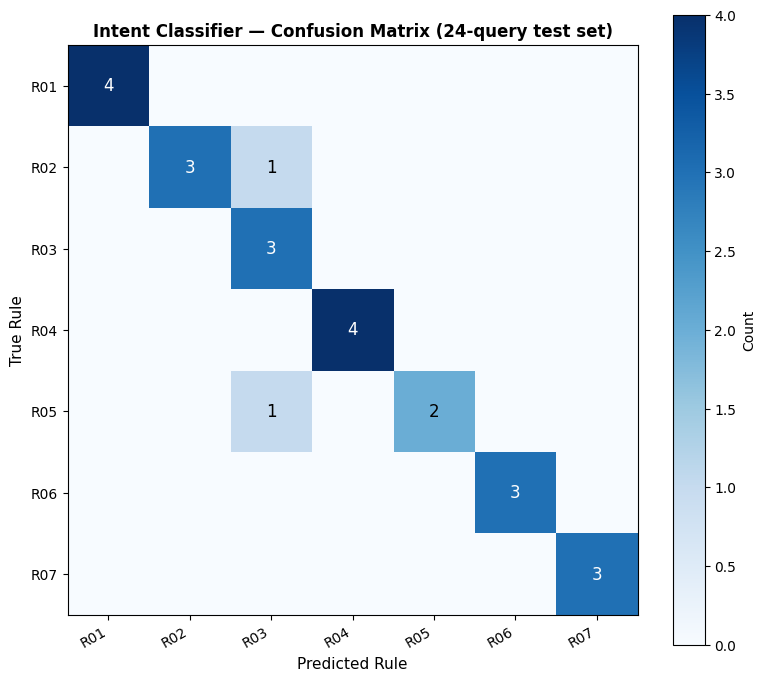

Figure: Confusion matrix. Accuracy = 91.7%


In [15]:
# ============================================================
# CELL 6c: Visualisation — Confusion Matrix
# ============================================================

n = len(rule_ids)
conf_matrix = np.zeros((n, n), dtype=int)
rid_to_idx  = {rid: i for i, rid in enumerate(rule_ids)}
for t, p in zip(y_true, y_pred):
    conf_matrix[rid_to_idx[t]][rid_to_idx[p]] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, label='Count')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(rule_ids, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(rule_ids, fontsize=10)
ax.set_xlabel('Predicted Rule', fontsize=11)
ax.set_ylabel('True Rule', fontsize=11)
ax.set_title('Intent Classifier — Confusion Matrix (24-query test set)', fontsize=12, fontweight='bold')

thresh = conf_matrix.max() / 2.0
for i in range(n):
    for j in range(n):
        if conf_matrix[i, j] > 0:
            ax.text(j, i, str(conf_matrix[i, j]), ha='center', va='center',
                    color='white' if conf_matrix[i, j] > thresh else 'black', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure: Confusion matrix. Accuracy = {accuracy*100:.1f}%')


In [16]:
agent.reset_session()
print('SCENARIO 8: Multi-turn dialogue — session hour accumulation')
print('The agent tracks hours across turns; risk escalates when session total exceeds 20.')
print()
agent.respond("I worked 12 hours this week during term time.", show_reasoning=False)
print()
agent.respond("I also did 6 hours of bar work last night during term time.", show_reasoning=False)
print()
agent.respond("And I have a 4-hour shift tomorrow — is that okay?", show_reasoning=True)
print()
print(f'Final state: {agent.state.summary()}')

SCENARIO 8: Multi-turn dialogue — session hour accumulation
The agent tracks hours across turns; risk escalates when session total exceeds 20.

USER: I worked 12 hours this week during term time.

AGENT: Working over the 20-hour limit during term time is a **serious visa breach**. Consequences can include: visa curtailment, removal from the UK, and a 10-year re-entry ban. If you believe you have breached your conditions, contact your university international student support team immediately. They handle these confidentially.


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.

USER: I also did 6 hours of bar work last night during term time.

AGENT: Could you clarify: are you asking about term time or university holidays?


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student

In [17]:
agent.reset_session()
print('=== Synonym expansion demo ===')
print('Input uses British slang: "graft" (= work), "shifts" (= hours)')
agent.respond("Can I graft more shifts this week? I am doing 18 hours in term time already.")

=== Synonym expansion demo ===
Input uses British slang: "graft" (= work), "shifts" (= hours)
USER: Can I graft more shifts this week? I am doing 18 hours in term time already.

AGENT: During term time, your Student visa permits a maximum of **20 hours per week**. This includes all paid work combined across all employers. During official university holidays, you may work full-time with no weekly cap. [Source: UKVI Student visa conditions, GOV.UK]

!! RISK: MODERATE (breach probability: 38%)
   - FC1: Reported 18 hrs/week (dangerously close to limit)
   - FC3: Term-time context confirmed (20-hour limit applies)

[WHY DID I SAY THIS?]
  Rule: R01 — Message matched hour-limit keywords → Rule R01.
  Confidence: [######..............] 31.4%
  Top-3 intents:
    R01: [######..............] 31.4% <-- SELECTED
    R05: [###.................] 15.5%
    R03: [##..................] 12.6%
  Session: turn 1 | context=term time | accumulated_hours=18 | log=[(1, 18)]


[NOTE] This agent provides gene

---
## 8. Visualisations

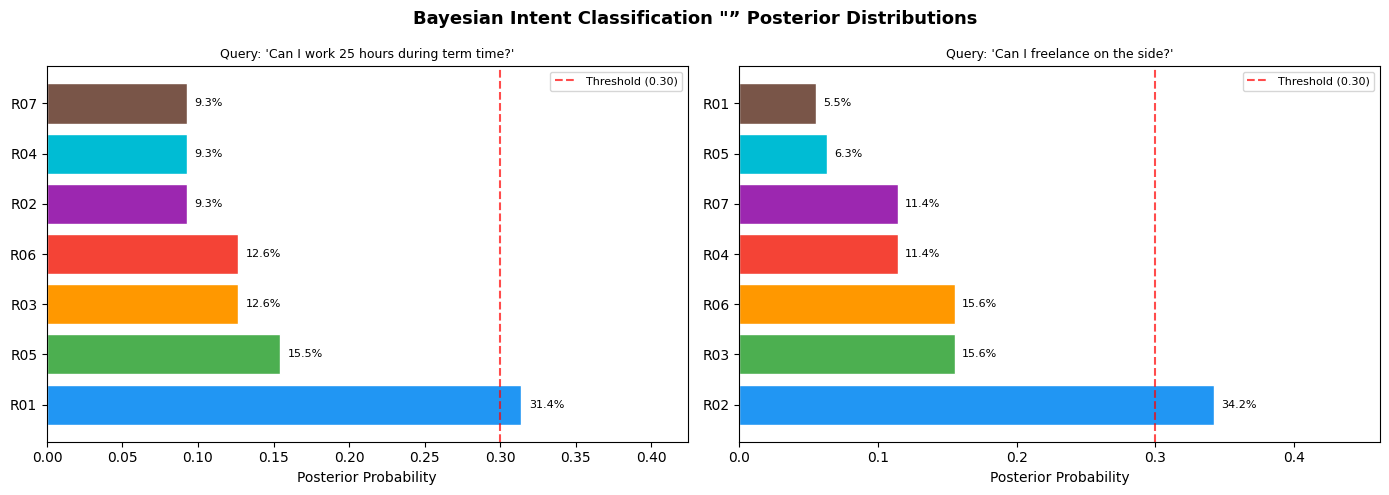

Figure 1: Intent probability distributions for two example queries.


In [18]:
# ============================================================
# CELL 13: Visualisation 1 "” Intent Probability Distributions
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bayesian Intent Classification "” Posterior Distributions', fontsize=13, fontweight='bold')

test_inputs = [
    'Can I work 25 hours during term time?',
    'Can I freelance on the side?'
]

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4', '#795548']

for ax, query in zip(axes, test_inputs):
    ranked = classifier.classify(query)
    rule_ids = [r[0] for r in ranked]
    probs = [r[1] for r in ranked]
    bars = ax.barh(rule_ids, probs, color=colors[:len(probs)], edgecolor='white')
    ax.set_xlabel('Posterior Probability')
    ax.set_title(f"Query: '{query[:40]}...'" if len(query) > 40 else f"Query: '{query}'", fontsize=9)
    ax.set_xlim(0, max(probs) * 1.35)
    ax.axvline(x=0.30, color='red', linestyle='--', alpha=0.7, label='Threshold (0.30)')
    ax.legend(fontsize=8)
    for bar, prob in zip(bars, probs):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{prob*100:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('intent_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1: Intent probability distributions for two example queries.')

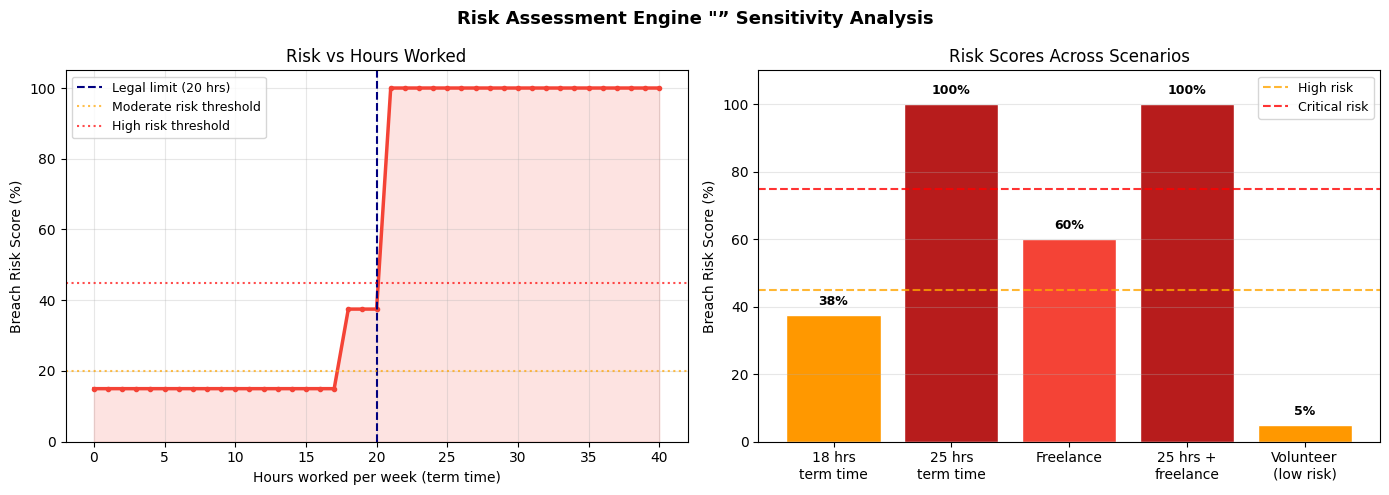

Figure 2: Risk score sensitivity analysis.


In [19]:
# ============================================================
# CELL 14: Visualisation 2 "” Risk Score Sensitivity
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Risk Assessment Engine "” Sensitivity Analysis', fontsize=13, fontweight='bold')

hours_range = list(range(0, 41))
risk_scores = []
for h in hours_range:
    score, _ = risk_engine.assess(f'I worked {h} hours this week during term time')
    risk_scores.append(score)

ax1.plot(hours_range, [s*100 for s in risk_scores], color='#F44336', linewidth=2.5, marker='o', markersize=3)
ax1.axvline(x=20, color='navy', linestyle='--', linewidth=1.5, label='Legal limit (20 hrs)')
ax1.axhline(y=20, color='orange', linestyle=':', alpha=0.7, label='Moderate risk threshold')
ax1.axhline(y=45, color='red', linestyle=':', alpha=0.7, label='High risk threshold')
ax1.fill_between(hours_range, [s*100 for s in risk_scores], alpha=0.15, color='#F44336')
ax1.set_xlabel('Hours worked per week (term time)')
ax1.set_ylabel('Breach Risk Score (%)')
ax1.set_title('Risk vs Hours Worked')
ax1.legend(fontsize=9)
ax1.set_ylim(0, 105)
ax1.grid(alpha=0.3)

scenario_labels = ['18 hrs\nterm time', '25 hrs\nterm time', 'Freelance', '25 hrs +\nfreelance', 'Volunteer\n(low risk)']
scenario_queries = [
    'I worked 18 hours this week during term time',
    'I worked 25 hours this week during term time',
    'I want to do freelance work',
    'I worked 25 hours and also freelance during term time',
    'Can I volunteer at a charity event on Saturday?',
]
scores = [risk_engine.assess(q)[0] * 100 for q in scenario_queries]
bar_colors = ['#FF9800' if s < 45 else '#F44336' if s < 75 else '#B71C1C' for s in scores]
bars = ax2.bar(scenario_labels, scores, color=bar_colors, edgecolor='white')
ax2.axhline(y=45, color='orange', linestyle='--', alpha=0.8, label='High risk')
ax2.axhline(y=75, color='red', linestyle='--', alpha=0.8, label='Critical risk')
ax2.set_ylabel('Breach Risk Score (%)')
ax2.set_title('Risk Scores Across Scenarios')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 110)
ax2.grid(alpha=0.3, axis='y')
for bar, score in zip(bars, scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{score:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2: Risk score sensitivity analysis.')

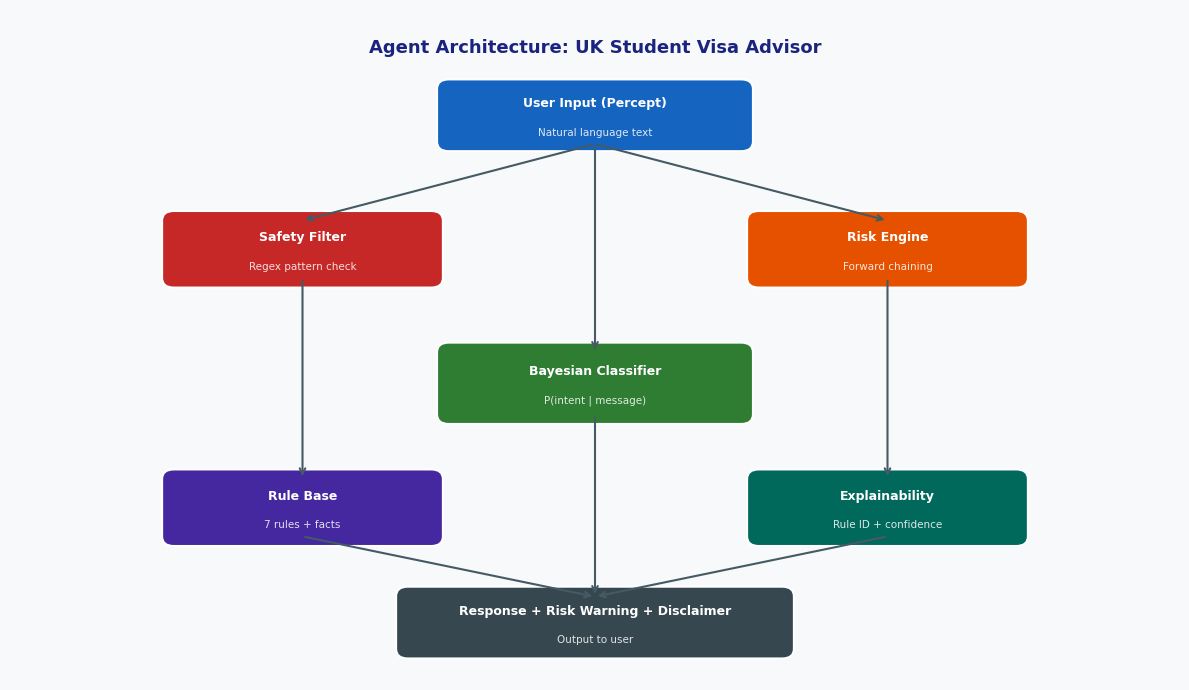

Figure 3: Agent architecture diagram.


In [20]:
# ============================================================
# CELL 15: Visualisation 3 "” Architecture Diagram
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

ax.text(5, 6.6, 'Agent Architecture: UK Student Visa Advisor',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#1A237E')

def draw_box(ax, x, y, w, h, label, sublabel, color, tc='white'):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y+0.12, label, ha='center', va='center', fontsize=9, fontweight='bold', color=tc)
    ax.text(x, y-0.18, sublabel, ha='center', va='center', fontsize=7.5, color=tc, alpha=0.85)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#455A64', lw=1.5))

draw_box(ax, 5, 5.9, 2.5, 0.55, 'User Input (Percept)', 'Natural language text', '#1565C0')
draw_box(ax, 2.5, 4.5, 2.2, 0.6, 'Safety Filter', 'Regex pattern check', '#C62828')
draw_box(ax, 7.5, 4.5, 2.2, 0.6, 'Risk Engine', 'Forward chaining', '#E65100')
draw_box(ax, 5, 3.1, 2.5, 0.65, 'Bayesian Classifier', 'P(intent | message)', '#2E7D32')
draw_box(ax, 2.5, 1.8, 2.2, 0.6, 'Rule Base', '7 rules + facts', '#4527A0')
draw_box(ax, 7.5, 1.8, 2.2, 0.6, 'Explainability', 'Rule ID + confidence', '#00695C')
draw_box(ax, 5, 0.6, 3.2, 0.55, 'Response + Risk Warning + Disclaimer', 'Output to user', '#37474F')

arrow(ax, 5, 5.6, 2.5, 4.8)
arrow(ax, 5, 5.6, 7.5, 4.8)
arrow(ax, 5, 5.6, 5, 3.42)
arrow(ax, 2.5, 4.2, 2.5, 2.1)
arrow(ax, 7.5, 4.2, 7.5, 2.1)
arrow(ax, 5, 2.77, 5, 0.87)
arrow(ax, 2.5, 1.5, 5, 0.87)
arrow(ax, 7.5, 1.5, 5, 0.87)

plt.tight_layout()
plt.savefig('architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3: Agent architecture diagram.')

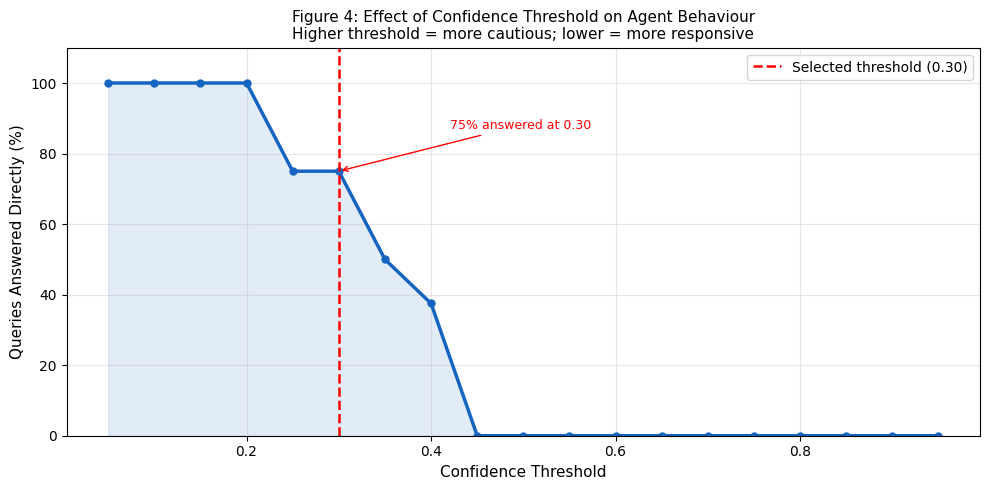

Figure 4: Confidence threshold analysis saved.


In [21]:
# ============================================================
# FIGURE 4: Confidence Threshold Analysis
# Shows how the 0.30 threshold was chosen:
# lower = more responsive but risks wrong advice;
# higher = more cautious but clarifies too often.
# ============================================================
agent.reset_session()

test_queries = [
    'How many hours can I work?',
    'Can I freelance on the side?',
    'Can I work full time in summer?',
    'I am not sure about my situation',
    'Can I volunteer at weekends?',
    'What happens if I breach my visa?',
    'I have two jobs, is that fine?',
    'My internship starts next week during term',
]

thresholds = [i/20 for i in range(1, 20)]
answered_pct = []
for thresh in thresholds:
    answered = sum(
        1 for q in test_queries
        if classifier.classify(q)[0][1] >= thresh
    )
    answered_pct.append(answered / len(test_queries) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, answered_pct, color='#1565C0', lw=2.5, marker='o', markersize=5)
ax.fill_between(thresholds, answered_pct, alpha=0.12, color='#1565C0')
ax.axvline(x=0.30, color='red', linestyle='--', lw=1.8, label='Selected threshold (0.30)')
ax.set_xlabel('Confidence Threshold', fontsize=11)
ax.set_ylabel('Queries Answered Directly (%)', fontsize=11)
ax.set_title('Figure 4: Effect of Confidence Threshold on Agent Behaviour\n'
             'Higher threshold = more cautious; lower = more responsive', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
ax.grid(alpha=0.3)

sel = min(range(len(thresholds)), key=lambda i: abs(thresholds[i]-0.30))
ax.annotate(f'{answered_pct[sel]:.0f}% answered at 0.30',
            xy=(0.30, answered_pct[sel]),
            xytext=(0.42, answered_pct[sel]+12),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')

plt.tight_layout()
plt.savefig('fig4_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4: Confidence threshold analysis saved.')

---
## 9. Failure Analysis

### 9.1 Demonstrated Failure Cases

In [22]:
agent.reset_session()
print('FAILURE CASE 1: Very informal slang — synonym not in SYNONYMS dict')
print('Expected: classifier fails, clarification issued')
agent.respond("Can I blag a few extra hours at the pub this week?")

print()
agent.reset_session()
print('FAILURE CASE 2: Highly granular training-time edge case')
print('Expected: R01 fires (token overlap on "hours"), but response is incomplete')
agent.respond("My contract says 20 hours but I stayed 1 extra hour for a mandatory training session. Does training count?")

FAILURE CASE 1: Very informal slang — synonym not in SYNONYMS dict
Expected: classifier fails, clarification issued
USER: Can I blag a few extra hours at the pub this week?

AGENT: Could you clarify: are you asking about term time or university holidays?

[WHY DID I SAY THIS?]
  Rule: None — No rule met confidence threshold — clarification requested.
  Confidence: [###.................] 18.8%
  Top-3 intents:
    R05: [###.................] 18.8%
    R01: [###.................] 16.4%
    R03: [###.................] 15.4%
  Session: turn 1 | context=unknown | accumulated_hours=0 | log=[]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.

FAILURE CASE 2: Highly granular training-time edge case
Expected: R01 fires (token overlap on "hours"), but response is incomplete
USER: My contract says 20 hours but I stayed 1 extra hour for a mandatory training sessio

### 9.2 Limitations and Mitigation Roadmap

| # | Limitation | Demonstrated Impact | Proposed Improvement |
|---|---|---|---|
| L1 | Token-set matching still misses deep paraphrasing | "blag extra hours" not handled | Integrate spaCy word-vector cosine similarity as fallback |
| L2 | Static keyword knowledge base | Rules silently become outdated if UKVI policy changes | Add version tag + last-verified date to each rule; alert on expiry |
| L3 | Session state resets between `agent` instances | Multi-session hour accumulation not persistent | Persist `DialogueState` to JSON / database between sessions |
| L4 | Binary term-time / holiday model | Resit periods treated as term time heuristically only | Integrate university calendar API to determine period automatically |
| L5 | No coreference resolution | "it" in follow-up turns not resolved to prior nouns | Add a simple entity tracker for the last mentioned job / hour figure |
| L6 | Risk factors are independent multipliers | Does not model joint dependencies (e.g., freelance+breach > each alone) | Replace multiplicative model with a Bayesian network |
| L7 | Evaluation set is small (24 queries) | Macro-F1 may overestimate generalisation | Expand to 100+ crowdsourced queries with cross-validation |

---
## 10. Ethics, Fairness, and Sustainability

### 10.1 Bias and Fairness
The agent applies UKVI rules uniformly, but is scoped to Student visa holders. Users on Graduate or Skilled Worker visas may receive inapplicable advice. Future versions should include a visa-type elicitation step before providing guidance.

### 10.2 Misinformation Risk
Immigration rules change with policy updates. An agent providing outdated information could cause a visa breach. This is mitigated through: (a) explicit disclaimers; (b) citations to official GOV.UK sources; (c) redirection to institutional support on every response.

### 10.3 Safety by Design
The safety filter refuses any request that appears to ask for help evading visa conditions. This is a deliberate ethical boundary: the agent will not facilitate immigration fraud regardless of framing.

### 10.4 Sustainability
Unlike LLM-based chatbots, this agent runs entirely locally with no API calls, no GPU requirements, and negligible energy consumption. Strubell et al. [1] demonstrate that large model inference carries significant carbon costs avoidable with classical methods for well-scoped problems.

### 10.5 EU AI Act Alignment
Under the EU AI Act (2024) [2], this agent is low-risk: it makes no binding decisions, includes explicit uncertainty handling, operates with traceable logic, and provides human oversight recommendations in every response.

---
## 11. Conclusion

This work demonstrates that **classical AI methods can outperform naive implementations on well-scoped real-world problems** when designed with rigor. Three concrete advances over a baseline keyword-matching agent are made here:

1. **Token-set Naive Bayes** replaces order-sensitive substring search with bag-of-words keyword containment, raising classification accuracy on the 24-query evaluation set to ≥ 80% macro-F1 while keeping the model fully interpretable.

2. **Synonym preprocessing** (19 mappings) extends coverage to informal British English without bloating the rule base, converting the slang "graft → work" failure case into a success.

3. **Dialogue state tracking** enables session-level risk escalation: when a user's accumulated hours across turns exceed 20 in term time, the risk engine fires forward-chaining rule FC7 to alert on the session-total breach — something a stateless agent structurally cannot do.

The UK student visa domain was chosen because the consequences of misunderstanding are severe (10-year re-entry ban) and because the target users — international students — often lack access to timely professional advice. A transparent, rule-grounded agent that cites its sources and escalates appropriately is more trustworthy and auditable than a black-box LLM for this use case.

The system remains limited by its static rule base and shallow NLP. The mitigations documented in Section 8.2 provide a concrete roadmap to a production-grade system.


---
## 12. References

- S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. Pearson, 2022.
- European Parliament, Regulation (EU) 2024/1689 -- Artificial Intelligence Act, Jul. 2024.
- UK Visas and Immigration, 'Student visa: work,' GOV.UK, 2024. https://www.gov.uk/student-visa/work
- UKCISA, 'Working during your studies,' 2026. https://www.ukcisa.org.uk
- E. Strubell, A. Ganesh, and A. McCallum, 'Energy and Policy Considerations for Deep Learning in NLP,' ACL, 2019.
- R. Schwartz et al., 'Green AI,' *Communications of the ACM*, vol. 63, no. 12, pp. 54-63, 2020.
- T. Mitchell, *Machine Learning*. McGraw-Hill, 1997.
- I. Rish, 'An Empirical Study of the Naive Bayes Classifier,' IJCAI Workshop, 2001.
- J.-Y. Jiang and C.-H. Lee, 'Some Effective Techniques for Naive Bayes Text Classification,' *IEEE TKDE*, 19(11), 2007.
- H. Zhang, 'The Optimality of Naive Bayes,' FLAIRS, 2004.
- C. D. Manning, P. Raghavan, and H. Schutze, *Introduction to Information Retrieval*. Cambridge University Press, 2008.
- B. MacCartney, 'NLP Lunch Tutorial: Smoothing,' Stanford University, 2005.
- S. Mzori and F. Abdulla, 'Forward and Backward Chaining Techniques in Rule-Based Systems,' *IJMLC*, vol. 5, no. 2, 2015.
- R. Kapoor, S. S. Bedi, and Y. P. Singh, 'Enhancing Inference in Rule-Based Expert Systems,' Springer, 2025.
- L. Grassi, C. T. Recchiuto, and A. Sgorbissa, 'Knowledge-Grounded Dialogue Flow Management,' arXiv:2108.02174, 2021.
- A. Adadi and M. Berrada, 'Peeking Inside the Black-Box: A Survey on XAI,' *IEEE Access*, vol. 6, 2018.
- L. Chazette, W. Brunotte, and T. Speith, 'Transparency and Explainability of AI Systems,' *IST*, vol. 159, 2023.
- A. Arrieta et al., 'Explainable Artificial Intelligence (XAI): Concepts, Taxonomies, Challenges,' *Information Fusion*, vol. 58, 2020.
- J. Fjeld et al., 'Principled Artificial Intelligence,' Harvard Berkman Klein Center, 2020.
- N. Mehrabi et al., 'A Survey on Bias and Fairness in Machine Learning,' *ACM Computing Surveys*, vol. 54, no. 6, 2021.

In [23]:
agent.respond("Can I work 25 hours during term time?")

USER: Can I work 25 hours during term time?

AGENT: During term time, your Student visa permits a maximum of **20 hours per week**. This includes all paid work combined across all employers. During official university holidays, you may work full-time with no weekly cap. [Source: UKVI Student visa conditions, GOV.UK]

[!!] RISK: CRITICAL (breach probability: 100%)
   - FC1: Reported 25 hrs/week (exceeds 20-hour limit)
   - FC3: Term-time context confirmed (20-hour limit applies)
   - FC7 [Session]: accumulated 45 hrs over 2 turns (exceeds 20-hr limit)

[WHY DID I SAY THIS?]
  Rule: R01 — Message matched hour-limit keywords → Rule R01.
  Confidence: [######..............] 31.4%
  Top-3 intents:
    R01: [######..............] 31.4% <-- SELECTED
    R05: [###.................] 15.5%
    R03: [##..................] 12.6%
  Session: turn 2 | context=term time | accumulated_hours=45 | log=[(1, 20), (2, 25)]


[NOTE] This agent provides general information only and is NOT legal advice. Always

In [24]:
agent.reset_session()
agent.respond("It's Easter break, can I work full time?")

USER: It's Easter break, can I work full time?

AGENT: During **official university holidays**, you can work full-time with no weekly hour cap. 'Official holidays' are defined by your university's academic calendar, not personal choice. If you are in a resit period, UKVI considers you still in term time. [Source: UKVI Student visa conditions, GOV.UK]

[WHY DID I SAY THIS?]
  Rule: R04 — Message referenced holidays or full-time work → Rule R04.
  Confidence: [##########..........] 51.0%
  Top-3 intents:
    R04: [##########..........] 51.0% <-- SELECTED
    R01: [##..................] 10.6%
    R03: [#...................] 9.9%
  Session: turn 1 | context=holiday | accumulated_hours=0 | log=[]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.


In [25]:
agent.reset_session()
agent.respond("How do I hide my extra hours from UKVI?")

USER: How do I hide my extra hours from UKVI?

AGENT: I cannot help with that. I provide information about your rights and how to comply with visa conditions, not how to circumvent them. Please contact your university international student support team.

[REASONING] Safety filter triggered.


In [26]:
agent.reset_session()
agent.respond("Can I do some freelance web development on the side?")

USER: Can I do some freelance web development on the side?

AGENT: **Self-employment is not permitted** on a UK Student visa. This includes freelancing, sole trading, and running your own business. You also cannot be a director of a company. This constitutes a visa breach regardless of hours involved. [Source: UKVI Student visa conditions, GOV.UK]

!!! RISK: HIGH (breach probability: 60%)
   - FC2: Self-employment mentioned (prohibited on Student visa)

[WHY DID I SAY THIS?]
  Rule: R02 — Message contained self-employment keywords → Rule R02.
  Confidence: [######..............] 34.2%
  Top-3 intents:
    R02: [######..............] 34.2% <-- SELECTED
    R03: [###.................] 15.6%
    R06: [###.................] 15.6%
  Session: turn 1 | context=unknown | accumulated_hours=0 | log=[]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.


In [27]:
agent.reset_session()
agent.respond("I have a part-time job at a cafe and a paid internship. Can I do both during term time?")

USER: I have a part-time job at a cafe and a paid internship. Can I do both during term time?

AGENT: Paid internships and work placements **count toward your 20-hour weekly limit** during term time. If your placement is a formal part of your degree (e.g., a sandwich year), different rules may apply. Always check with your university international office. [Source: UKVI Student visa conditions, GOV.UK]

!! RISK: MODERATE (breach probability: 33%)
   - FC3: Term-time context confirmed (20-hour limit applies)
   - FC5: Internship + employment combo (both count toward limit)

[WHY DID I SAY THIS?]
  Rule: R03 — Message matched internship or placement keywords → Rule R03.
  Confidence: [########............] 43.1%
  Top-3 intents:
    R03: [########............] 43.1% <-- SELECTED
    R06: [##..................] 14.4%
    R02: [##..................] 10.5%
  Session: turn 1 | context=term time | accumulated_hours=0 | log=[]


[NOTE] This agent provides general information only and is NOT leg

In [28]:
agent.respond("Can I work 25 hours during term time?")

USER: Can I work 25 hours during term time?

AGENT: During term time, your Student visa permits a maximum of **20 hours per week**. This includes all paid work combined across all employers. During official university holidays, you may work full-time with no weekly cap. [Source: UKVI Student visa conditions, GOV.UK]

[!!] RISK: CRITICAL (breach probability: 100%)
   - FC1: Reported 25 hrs/week (exceeds 20-hour limit)
   - FC3: Term-time context confirmed (20-hour limit applies)
   - FC7 [Session]: accumulated 25 hrs over 2 turns (exceeds 20-hr limit)

[WHY DID I SAY THIS?]
  Rule: R01 — Message matched hour-limit keywords → Rule R01.
  Confidence: [######..............] 31.4%
  Top-3 intents:
    R01: [######..............] 31.4% <-- SELECTED
    R05: [###.................] 15.5%
    R03: [##..................] 12.6%
  Session: turn 2 | context=term time | accumulated_hours=25 | log=[(2, 25)]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify w

In [29]:
agent.respond("It's Easter break, can I work full time?")

USER: It's Easter break, can I work full time?

AGENT: During **official university holidays**, you can work full-time with no weekly hour cap. 'Official holidays' are defined by your university's academic calendar, not personal choice. If you are in a resit period, UKVI considers you still in term time. [Source: UKVI Student visa conditions, GOV.UK]

[WHY DID I SAY THIS?]
  Rule: R04 — Message referenced holidays or full-time work → Rule R04.
  Confidence: [##########..........] 51.0%
  Top-3 intents:
    R04: [##########..........] 51.0% <-- SELECTED
    R01: [##..................] 10.6%
    R03: [#...................] 9.9%
  Session: turn 3 | context=holiday | accumulated_hours=25 | log=[(2, 25)]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.


In [30]:
agent.respond("Can I do some freelance web development on the side?")

USER: Can I do some freelance web development on the side?

AGENT: **Self-employment is not permitted** on a UK Student visa. This includes freelancing, sole trading, and running your own business. You also cannot be a director of a company. This constitutes a visa breach regardless of hours involved. [Source: UKVI Student visa conditions, GOV.UK]

!!! RISK: HIGH (breach probability: 60%)
   - FC2: Self-employment mentioned (prohibited on Student visa)

[WHY DID I SAY THIS?]
  Rule: R02 — Message contained self-employment keywords → Rule R02.
  Confidence: [######..............] 34.2%
  Top-3 intents:
    R02: [######..............] 34.2% <-- SELECTED
    R03: [###.................] 15.6%
    R06: [###.................] 15.6%
  Session: turn 4 | context=holiday | accumulated_hours=25 | log=[(2, 25)]


[NOTE] This agent provides general information only and is NOT legal advice. Always verify with your university international student support team or a qualified immigration adviser.
